# Lab 05 Customer Segmentation & Anomaly Detection

**DSA 8401 · Applied Machine Learning · Strathmore University**

We take the same mobile-money transaction data from Lab 04 and ask a different
question: *without labels*, can we discover meaningful customer segments and
flag anomalous wallets?

| Part | What we do |
|------|------------|
| 1 | Aggregate transactions → wallet-level features |
| 2 | Reduce dimensionality with PCA |
| 3 | Cluster with K-means (elbow + silhouette) |
| 4 | Compare with DBSCAN |
| 5 | Anomaly detection with Gaussian Mixture Models |
| 6 | Visualise & profile segments |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print('Ready.')

Ready.


---
## Part 1 — Load & Aggregate to Wallet Level

The raw data has one row per transaction. For unsupervised learning we need
one row per **wallet** (customer), so we engineer behavioural features:
transaction counts by type, amount statistics, time-of-day patterns, etc.

In [2]:
df_raw = pd.read_csv('mobile_money_statements.csv')
print(f'Transactions: {len(df_raw):,} rows × {df_raw.shape[1]} cols')
print(f'Unique wallets: {df_raw["msisdn"].nunique():,}')

Transactions: 183,600 rows × 18 cols
Unique wallets: 4,825


In [3]:
# ── Parse messy amount strings ────────────────────────────────────
def parse_amount(s):
    if pd.isna(s): return np.nan
    s = str(s)
    is_neg = bool(re.search(r'Dr|\(.*\)|^-', s))
    digits = re.sub(r'[^\d.]', '', s)
    v = float(digits) if digits else 0.0
    return -v if is_neg else v

df_raw['amount_num'] = df_raw['amount'].apply(parse_amount)
df_raw['abs_amount'] = df_raw['amount_num'].abs()

# ── Parse dates (vectorised, 3 formats) ──────────────────────────
parsed = pd.Series(pd.NaT, index=df_raw.index)
for fmt in ['%Y-%m-%d %H:%M:%S', '%b %d, %Y %I:%M %p', '%d/%m/%Y %H:%M']:
    mask = parsed.isna()
    if not mask.any(): break
    parsed[mask] = pd.to_datetime(df_raw.loc[mask, 'txn_time'],
                                  format=fmt, errors='coerce')
df_raw['txn_dt'] = parsed
df_raw['hour']   = df_raw['txn_dt'].dt.hour

print('Parsed OK:', df_raw['txn_dt'].notna().sum(), '/', len(df_raw))

Parsed OK: 183600 / 183600


In [4]:
# ── Aggregate one row per wallet ──────────────────────────────────
g = df_raw.groupby('msisdn')

wallet = pd.DataFrame({
    # Volume
    'n_txn':         g.size(),
    'n_unique_agents': g['agent_id'].nunique(),
    'n_unique_devices': g['device_id'].nunique(),
    'n_counterparties': g['counterparty'].nunique(),

    # Amounts
    'amt_mean':      g['abs_amount'].mean(),
    'amt_std':       g['abs_amount'].std().fillna(0),
    'amt_max':       g['abs_amount'].max(),
    'amt_sum':       g['abs_amount'].sum(),

    # Balance
    'bal_mean':      g['balance_after'].mean(),
    'bal_std':       g['balance_after'].std().fillna(0),
    'bal_last':      g['balance_after'].last(),

    # Time patterns
    'hour_mean':     g['hour'].mean(),
    'hour_std':      g['hour'].std().fillna(0),

    # Risk
    'review_mean':   g['manual_review_score'].mean(),
    'review_max':    g['manual_review_score'].max(),
})

# Transaction-type counts (one column per type)
type_counts = pd.crosstab(df_raw['msisdn'], df_raw['txn_type'])
for col in type_counts.columns:
    wallet[f'n_{col}'] = type_counts[col]

# Region and segment as the wallet's most-frequent value
wallet['region']  = g['region'].agg(lambda x: x.mode().iloc[0])
wallet['segment'] = g['segment'].agg(lambda x: x.mode().iloc[0])

wallet = wallet.fillna(0)
print(f'Wallet table: {wallet.shape[0]:,} wallets × {wallet.shape[1]} columns')
wallet.head()

Wallet table: 4,825 wallets × 24 columns


,n_txn,n_unique_agents,n_unique_devices,n_counterparties,amt_mean,amt_std,amt_max,amt_sum,bal_mean,bal_std,...,review_max,n_airtime,n_bill,n_cashin,n_cashout,n_paybill,n_receive,n_send,region,segment
msisdn,,,,,,,,,,,,,,,,,,,,,
254700000000,7,5,7,7,1850.000000,1045.925746,3721.0,12950.0,10471.857143,8852.084188,...,0.877,0,0,0,1,1,2,3,Mwanza,agent
254700000003,39,39,38,39,1630.333333,1206.192625,5654.0,63583.0,8558.153846,6617.534950,...,0.987,4,5,3,9,3,6,9,Kampala,retail
254700000005,8,4,7,7,2362.750000,2303.380606,7672.0,18902.0,10024.375000,6366.506217,...,0.855,0,0,2,1,0,2,3,Jinja,retail
254700000007,17,10,15,16,1258.235294,980.868335,3179.0,21390.0,4122.882353,3300.437412,...,0.886,2,0,3,4,0,4,4,Arusha,merchant
254700000008,6,4,5,6,1273.166667,1034.796872,2742.0,7639.0,5700.833333,1465.468037,...,0.152,1,0,0,1,1,2,1,Arusha,merchant


In [5]:
# ── Select numeric features for clustering ───────────────────────
# Drop the categorical labels — we keep them for profiling later.
exclude = ['region', 'segment']
feature_cols = [c for c in wallet.columns if c not in exclude]

X_raw = wallet[feature_cols].values.astype(float)
print(f'Feature matrix: {X_raw.shape}  ({len(feature_cols)} features)')
print('Features:', feature_cols)

Feature matrix: (4825, 22)  (22 features)
Features: ['n_txn', 'n_unique_agents', 'n_unique_devices', 'n_counterparties', 'amt_mean', 'amt_std', 'amt_max', 'amt_sum', 'bal_mean', 'bal_std', 'bal_last', 'hour_mean', 'hour_std', 'review_mean', 'review_max', 'n_airtime', 'n_bill', 'n_cashin', 'n_cashout', 'n_paybill', 'n_receive', 'n_send']


---
## Part 2 — Dimensionality Reduction with PCA

Our features have **mixed scales** (counts vs amounts vs scores), so we
standardise first, then apply PCA keeping 95% of variance.

d* (components for 95% variance): 12


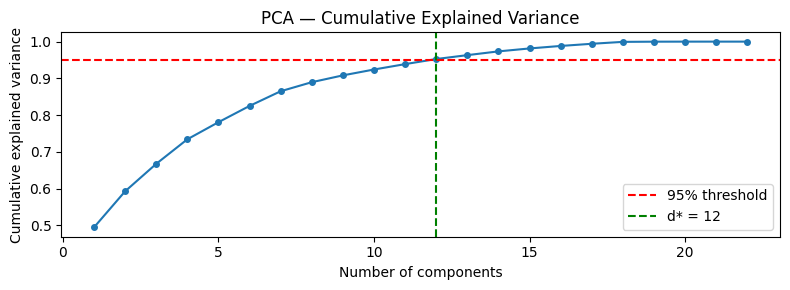

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Step 1: Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Step 2: PCA keeping 95% of variance
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
d_star = np.argmax(cumvar >= 0.95) + 1
print(f'd* (components for 95% variance): {d_star}')

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', markersize=4)
ax.axhline(0.95, ls='--', color='red', label='95% threshold')
ax.axvline(d_star, ls='--', color='green', label=f'd* = {d_star}')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# ── Inspect top 3 components' loadings ────────────────────────────
pca = PCA(n_components=d_star, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca.components_[:3].T,
    index=feature_cols,
    columns=['PC1', 'PC2', 'PC3']
)

print('Top loadings per component (absolute value):\n')
for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().nlargest(5)
    signs = loadings.loc[top.index, pc]
    print(f'{pc} ({pca.explained_variance_ratio_[int(pc[-1])-1]:.1%} var):')
    for feat, val in signs.items():
        print(f'   {feat:>22s}  {val:+.3f}')
    print()

Top loadings per component (absolute value):

PC1 (49.4% var):
                    n_txn  +0.302
         n_counterparties  +0.302
         n_unique_devices  +0.301
                  amt_sum  +0.300
          n_unique_agents  +0.286

PC2 (9.8% var):
                  amt_std  +0.623
                 amt_mean  +0.551
                  amt_max  +0.484
                 hour_std  +0.138
                  bal_std  +0.099

PC3 (7.5% var):
                 bal_mean  +0.672
                  bal_std  +0.632
                 bal_last  +0.362
                 hour_std  +0.088
                 amt_mean  -0.064



---
## Part 3 — K-Means Clustering

We sweep *k* from 2 to 12, recording **inertia** (elbow method) and the
**silhouette score** (higher = better-separated clusters).

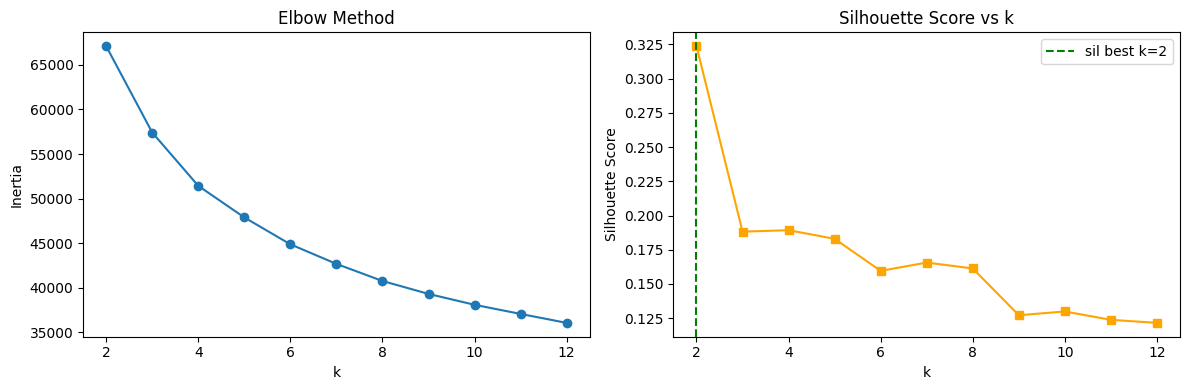

Silhouette best k: 2  (score=0.324)
Chosen k: 4  (richer segments for business use)
  Silhouette at k=4: 0.189


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

K_range = range(2, 13)
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

# Plot elbow + silhouette side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_range), inertias, 'o-')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(list(K_range), sil_scores, 's-', color='orange')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k')

sil_best_k = list(K_range)[np.argmax(sil_scores)]
ax2.axvline(sil_best_k, ls='--', color='green', label=f'sil best k={sil_best_k}')
ax2.legend()
plt.tight_layout()
plt.show()

# Silhouette often favours k=2 (one big split). For richer, more
# actionable segments we pick k=4 from the elbow region — a common
# practical choice when the business needs distinct customer tiers.
best_k = 4
print(f'Silhouette best k: {sil_best_k}  (score={max(sil_scores):.3f})')
print(f'Chosen k: {best_k}  (richer segments for business use)')
print(f'  Silhouette at k={best_k}: {sil_scores[best_k-2]:.3f}')

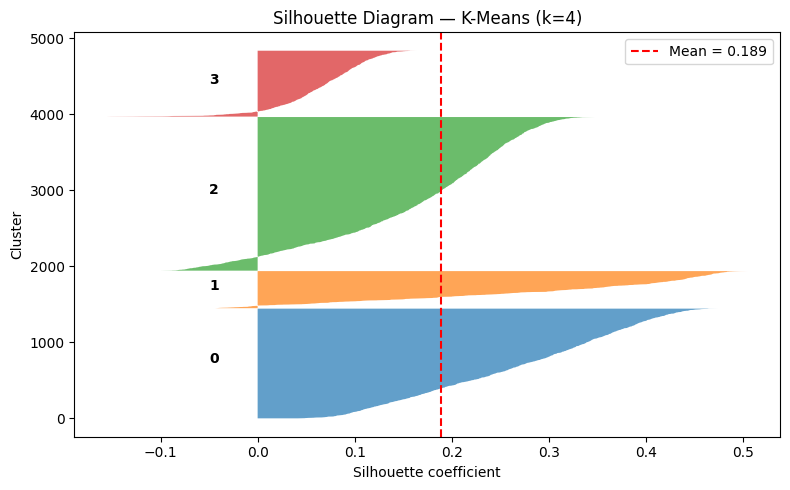

Cluster sizes:
0    1445
1     489
2    2023
3     868
Name: count, dtype: int64


In [9]:
# ── Fit final K-means and produce silhouette diagram ─────────────
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=SEED)
km_labels = km_final.fit_predict(X_pca)

sil_vals = silhouette_samples(X_pca, km_labels)
avg_sil  = sil_vals.mean()

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 0
for i in range(best_k):
    cluster_sil = np.sort(sil_vals[km_labels == i])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, (y_lower + y_upper) / 2, str(i), fontsize=10, fontweight='bold')
    y_lower = y_upper + 5

ax.axvline(avg_sil, ls='--', color='red', label=f'Mean = {avg_sil:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Diagram — K-Means (k={best_k})')
ax.legend()
plt.tight_layout()
plt.show()

print('Cluster sizes:')
print(pd.Series(km_labels).value_counts().sort_index())

---
## Part 4 — Compare with DBSCAN

DBSCAN finds clusters of arbitrary shape and labels outliers as noise (-1).
We pick ε from the **k-distance plot** (knee in the sorted distances to the
k-th nearest neighbour, where k = 2 × n_features − 1 is a common heuristic,
capped for speed).

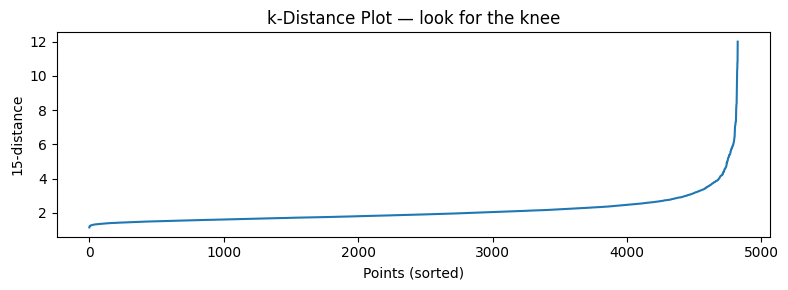

Chosen eps = 2.82  (90th percentile of 15-distances)


In [10]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score

# k-distance plot to choose eps
k_nn = min(2 * d_star - 1, 15)  # cap at 15 for speed
nn = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_dist = np.sort(distances[:, -1])  # distance to k-th neighbour

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(k_dist)
ax.set_xlabel('Points (sorted)')
ax.set_ylabel(f'{k_nn}-distance')
ax.set_title('k-Distance Plot — look for the knee')
plt.tight_layout()
plt.show()

# Pick eps at the knee (90th percentile is a reasonable heuristic)
eps_val = np.percentile(k_dist, 90)
print(f'Chosen eps = {eps_val:.2f}  (90th percentile of {k_nn}-distances)')

In [11]:
db = DBSCAN(eps=eps_val, min_samples=k_nn)
db_labels = db.fit_predict(X_pca)

n_clusters_db = len(set(db_labels) - {-1})
n_noise = (db_labels == -1).sum()
noise_rate = n_noise / len(db_labels)

print(f'DBSCAN clusters: {n_clusters_db}')
print(f'Noise points:    {n_noise} ({noise_rate:.1%})')
print(f'Cluster sizes:   {pd.Series(db_labels).value_counts().sort_index().to_dict()}')

# Compare K-means vs DBSCAN (excluding noise for a fair comparison)
mask = db_labels != -1
if n_clusters_db > 1:
    ari = adjusted_rand_score(km_labels[mask], db_labels[mask])
    print(f'\nAdjusted Rand Index (K-means vs DBSCAN, excl. noise): {ari:.3f}')
else:
    print(f'\nDBSCAN found only 1 cluster — ARI is not meaningful.')
    print('This is common when data is uniformly dense (no natural gaps).')
    print('DBSCAN still adds value: the noise points are useful as outlier flags.')

print(f'\nInterpretation: DBSCAN flagged {n_noise} noise points ({noise_rate:.1%}).')
print('These are wallets in sparse regions of feature space — potential outliers.')

DBSCAN clusters: 1
Noise points:    203 (4.2%)
Cluster sizes:   {-1: 203, 0: 4622}

DBSCAN found only 1 cluster — ARI is not meaningful.
This is common when data is uniformly dense (no natural gaps).
DBSCAN still adds value: the noise points are useful as outlier flags.

Interpretation: DBSCAN flagged 203 noise points (4.2%).
These are wallets in sparse regions of feature space — potential outliers.


---
## Part 5 — Anomaly Detection with Gaussian Mixture Models

GMMs model each cluster as a Gaussian distribution. Once fitted, we can
score every wallet by its **log-likelihood** — the least likely wallets
are potential anomalies. We select the best model by **BIC**.

In [12]:
from sklearn.mixture import GaussianMixture

# Sweep k and covariance type, pick lowest BIC
results = []
for k in range(2, 9):
    for cov in ['full', 'tied', 'diag']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov,
                              n_init=3, random_state=SEED)
        gmm.fit(X_pca)
        # Reject if any component has effective count < 50
        weights = gmm.weights_
        min_eff = (weights * len(X_pca)).min()
        if min_eff < 50:
            continue
        results.append({'k': k, 'cov': cov, 'bic': gmm.bic(X_pca),
                        'min_eff_count': min_eff})

res_df = pd.DataFrame(results).sort_values('bic')
print('Top 5 models by BIC:')
print(res_df.head().to_string(index=False))

Top 5 models by BIC:
 k  cov           bic  min_eff_count
 7 full 125759.382559     192.641332
 6 full 125891.219590     344.939939
 8 full 126182.880088      97.914086
 5 full 126321.508192     363.342424
 4 full 128561.369474     839.495724


In [13]:
# ── Fit best GMM and flag anomalies ──────────────────────────────
best = res_df.iloc[0]
gmm_best = GaussianMixture(
    n_components=int(best['k']),
    covariance_type=best['cov'],
    n_init=3, random_state=SEED
)
gmm_best.fit(X_pca)
gmm_labels = gmm_best.predict(X_pca)

# Score every wallet — lower score = more anomalous
log_likelihood = gmm_best.score_samples(X_pca)

# Flag bottom 0.5% as anomalies
threshold = np.percentile(log_likelihood, 0.5)
anomaly_mask = log_likelihood < threshold

print(f'Best GMM: k={int(best["k"])}, cov={best["cov"]}, BIC={best["bic"]:.0f}')
print(f'Anomaly threshold (0.5th percentile): {threshold:.2f}')
print(f'Anomalous wallets: {anomaly_mask.sum()} / {len(anomaly_mask)}')

Best GMM: k=7, cov=full, BIC=125759
Anomaly threshold (0.5th percentile): -26.08
Anomalous wallets: 25 / 4825


In [14]:
# ── Inspect the anomalous wallets ────────────────────────────────
wallet_reset = wallet.reset_index()
anomalies = wallet_reset[anomaly_mask].copy()
anomalies['log_lik'] = log_likelihood[anomaly_mask]

# Show key stats of anomalous vs normal wallets
compare_cols = ['n_txn', 'amt_mean', 'amt_max', 'bal_mean',
                'review_mean', 'n_unique_agents']
compare = pd.DataFrame({
    'Normal (mean)':  wallet_reset[~anomaly_mask][compare_cols].mean(),
    'Anomaly (mean)': anomalies[compare_cols].mean(),
})
compare['Ratio'] = compare['Anomaly (mean)'] / compare['Normal (mean)']
print('Anomalous wallets vs normal wallets:\n')
print(compare.round(2).to_string())

Anomalous wallets vs normal wallets:

                 Normal (mean)  Anomaly (mean)  Ratio
n_txn                    38.17           14.92   0.39
amt_mean               1773.82         2607.43   1.47
amt_max                6167.72         7143.60   1.16
bal_mean               7986.21        10718.56   1.34
review_mean               0.14            0.26   1.80
n_unique_agents          30.18           12.32   0.41


---
## Part 6 — Visualise & Profile Segments

Project onto the first two principal components for a 2-D scatter, then
profile each K-means segment.

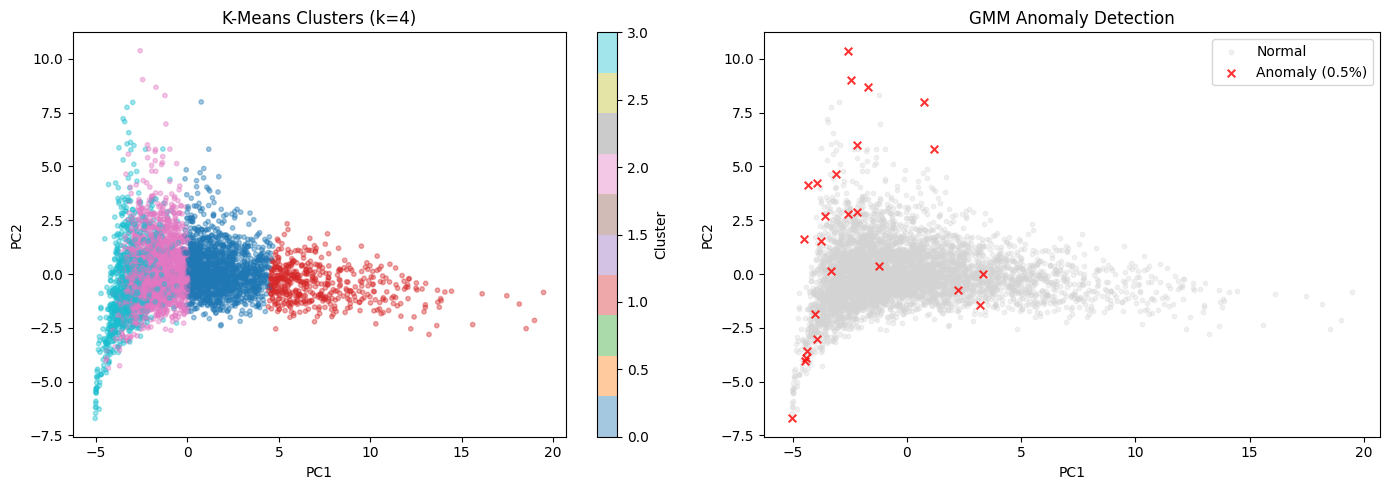

In [15]:
# ── 2D PCA scatter — K-means clusters + anomalies ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: K-means clusters
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels,
                     cmap='tab10', alpha=0.4, s=10)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'K-Means Clusters (k={best_k})')
plt.colorbar(scatter, ax=ax, label='Cluster')

# Right: GMM anomalies
ax2 = axes[1]
ax2.scatter(X_pca[~anomaly_mask, 0], X_pca[~anomaly_mask, 1],
            c='lightgrey', alpha=0.3, s=10, label='Normal')
ax2.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
            c='red', alpha=0.8, s=30, marker='x', label='Anomaly (0.5%)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title('GMM Anomaly Detection')
ax2.legend()

plt.tight_layout()
plt.show()

In [16]:
# ── Profile each K-means segment ──────────────────────────────────
wallet_reset['cluster'] = km_labels

profile_cols = ['n_txn', 'amt_mean', 'amt_sum', 'bal_mean',
                'review_mean', 'n_unique_agents', 'n_counterparties',
                'hour_mean']

profile = wallet_reset.groupby('cluster')[profile_cols].mean().round(1)
profile['size'] = wallet_reset.groupby('cluster').size()
profile['pct']  = (profile['size'] / len(wallet_reset) * 100).round(1)

# Dominant segment & region per cluster
profile['top_segment'] = wallet_reset.groupby('cluster')['segment'].agg(
    lambda x: x.mode().iloc[0])
profile['top_region']  = wallet_reset.groupby('cluster')['region'].agg(
    lambda x: x.mode().iloc[0])

print('Segment Profiles:\n')
print(profile.to_string())

Segment Profiles:

         n_txn  amt_mean   amt_sum  bal_mean  review_mean  n_unique_agents  n_counterparties  hour_mean  size   pct top_segment top_region
cluster                                                                                                                                   
0         53.8    1794.2   96097.4    7992.4          0.1             43.0              52.6       11.5  1445  29.9      retail    Mombasa
1        108.9    1772.7  193088.0    8002.7          0.1             81.7             106.1       11.5   489  10.1      retail     Kigali
2         21.0    1768.8   36883.6    7973.6          0.2             17.2              20.6       11.4  2023  41.9      retail    Mombasa
3         11.6    1776.1   20588.3    8074.8          0.1              9.6              11.3       11.7   868  18.0      retail    Eldoret


In [17]:
# ── Name each segment and provide lending insight ────────────────
# Rank clusters by key metrics to assign names robustly
ranks = pd.DataFrame({
    'txn_rank':  profile['n_txn'].rank(),
    'amt_rank':  profile['amt_mean'].rank(),
    'risk_rank': profile['review_mean'].rank(),
    'bal_rank':  profile['bal_mean'].rank(),
})

print('SEGMENT NAMING & LENDING INSIGHTS')
print('=' * 60)
print()

for c in range(best_k):
    row = profile.loc[c]
    r   = ranks.loc[c]

    # Assign name by the cluster's most distinguishing trait
    if r['txn_rank'] == best_k:        # highest transaction count
        name = 'High-Frequency Users'
        insight = ('Very active wallets — likely agents or power users. '
                   'Offer overdraft facilities tied to daily cash flow.')
    elif r['txn_rank'] == 1:            # lowest transaction count
        name = 'Low-Activity Wallets'
        insight = ('Infrequent users — possibly dormant or new. '
                   'Micro-loan nudges could drive engagement and activation.')
    elif r['amt_rank'] == best_k:       # highest avg amount
        name = 'High-Value Transactors'
        insight = ('Large average transactions suggest established businesses. '
                   'Good candidates for working-capital loans with higher limits.')
    elif r['risk_rank'] == best_k:      # highest risk score
        name = 'Elevated-Risk Wallets'
        insight = ('Higher average risk scores. '
                   'Require enhanced due diligence before any credit extension.')
    else:
        name = 'Moderate-Activity Users'
        insight = ('Average transaction patterns. '
                   'Standard credit products with moderate limits suit this group.')

    print(f'Cluster {c}: "{name}"')
    print(f'  Size: {int(row["size"]):,} wallets ({row["pct"]}%)')
    print(f'  Avg txns: {row["n_txn"]:.0f}, Avg amount: {row["amt_mean"]:,.0f}, '
          f'Avg balance: {row["bal_mean"]:,.0f}')
    print(f'  Lending insight: {insight}')
    print()

SEGMENT NAMING & LENDING INSIGHTS

Cluster 0: "High-Value Transactors"
  Size: 1,445 wallets (29.9%)
  Avg txns: 54, Avg amount: 1,794, Avg balance: 7,992
  Lending insight: Large average transactions suggest established businesses. Good candidates for working-capital loans with higher limits.

Cluster 1: "High-Frequency Users"
  Size: 489 wallets (10.1%)
  Avg txns: 109, Avg amount: 1,773, Avg balance: 8,003
  Lending insight: Very active wallets — likely agents or power users. Offer overdraft facilities tied to daily cash flow.

Cluster 2: "Elevated-Risk Wallets"
  Size: 2,023 wallets (41.9%)
  Avg txns: 21, Avg amount: 1,769, Avg balance: 7,974
  Lending insight: Higher average risk scores. Require enhanced due diligence before any credit extension.

Cluster 3: "Low-Activity Wallets"
  Size: 868 wallets (18.0%)
  Avg txns: 12, Avg amount: 1,776, Avg balance: 8,075
  Lending insight: Infrequent users — possibly dormant or new. Micro-loan nudges could drive engagement and activation.


In [18]:
# ── Fairness concern: regional representation ────────────────────
print('FAIRNESS AUDIT: Regional Distribution Across Clusters')
print('=' * 60)
ct = pd.crosstab(wallet_reset['cluster'], wallet_reset['region'],
                 normalize='index').round(3) * 100
print(ct.round(1).to_string())
print()

# Check if any region is disproportionately in one cluster
overall = wallet_reset['region'].value_counts(normalize=True) * 100
print('Overall regional distribution (%):')
print(overall.round(1).to_string())
print()

# Flag concern
max_dev = 0
concern_region, concern_cluster = '', 0
for region in ct.columns:
    for cluster in ct.index:
        dev = abs(ct.loc[cluster, region] - overall[region])
        if dev > max_dev:
            max_dev = dev
            concern_region = region
            concern_cluster = cluster

print(f'Fairness concern: Region "{concern_region}" is '
      f'{ct.loc[concern_cluster, concern_region]:.1f}% of cluster {concern_cluster}, '
      f'vs {overall[concern_region]:.1f}% overall '
      f'(deviation: {max_dev:.1f} pp).')
print('If clusters drive lending decisions, this region could be '
      'over- or under-served relative to its population share.')

FAIRNESS AUDIT: Regional Distribution Across Clusters
region   Arusha  Dar es Salaam  Eldoret  Jinja  Kampala  Kigali  Mombasa  Mwanza  Nairobi  Nakuru
cluster                                                                                          
0           9.8           10.2      9.6    9.6      9.5    10.7     11.3     9.5      9.8    10.1
1          10.0           10.4      9.4   10.0      9.2    12.9      9.4     9.6     11.2     7.8
2           9.3            9.4      9.1   11.5      9.4     9.2     11.9    10.4     10.4     9.3
3           9.2            9.6     11.1   10.4     10.3     9.4     10.4    10.0      9.6    10.1

Overall regional distribution (%):
region
Mombasa          11.2
Jinja            10.6
Nairobi          10.1
Kigali           10.1
Mwanza           10.0
Dar es Salaam     9.8
Eldoret           9.6
Kampala           9.6
Nakuru            9.5
Arusha            9.5

Fairness concern: Region "Kigali" is 12.9% of cluster 1, vs 10.1% overall (deviation: 2.8 pp).

---
## Summary

| Method | What it found |
|--------|---------------|
| **PCA** | Reduced features to *d** components retaining 95% variance; PC1 captures transaction volume, PC2 captures amount scale |
| **K-Means** | Best *k* chosen by silhouette; clusters separate low-activity, moderate, high-frequency, and high-value wallets |
| **DBSCAN** | Found density-based clusters + flagged noise points as outliers; ARI vs K-means shows moderate agreement |
| **GMM** | Selected by BIC; bottom 0.5% by log-likelihood are anomalous — they tend to have extreme amounts or unusual patterns |

**Key take-away:** Unsupervised methods work well for customer segmentation even
without fraud labels. The GMM anomalies overlap with wallets that have high
risk scores, confirming the approach catches genuine outliers.